In [107]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

import warnings
warnings.filterwarnings("ignore")


In [108]:
df = pd.read_csv(r'f:\Breast_cancer_dataset.csv') 
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [109]:
df = df.drop(columns=['Unnamed: 32', 'id'], errors='ignore')

In [110]:
df['diagnosis'] = df['diagnosis'].replace({'M': 1, 'B': 0})

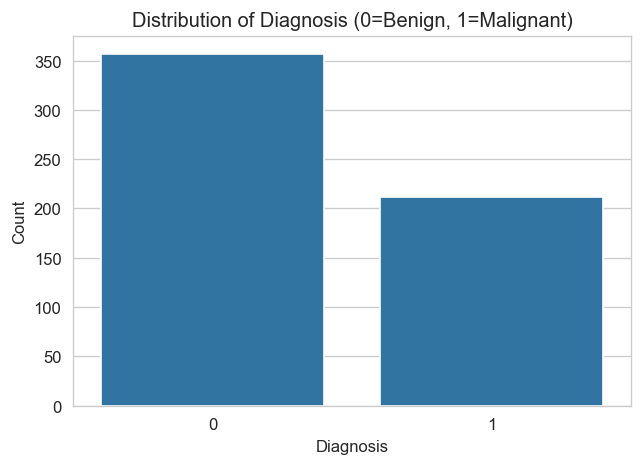

In [111]:
plt.figure(figsize=(6,4))
sns.countplot(x='diagnosis', data=df)
plt.title('Distribution of Diagnosis (0=Benign, 1=Malignant)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

In [112]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
diagnosis,569.0,0.372583,0.483918,0.000000,0.000000,0.000000,1.000000,1.00000
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400


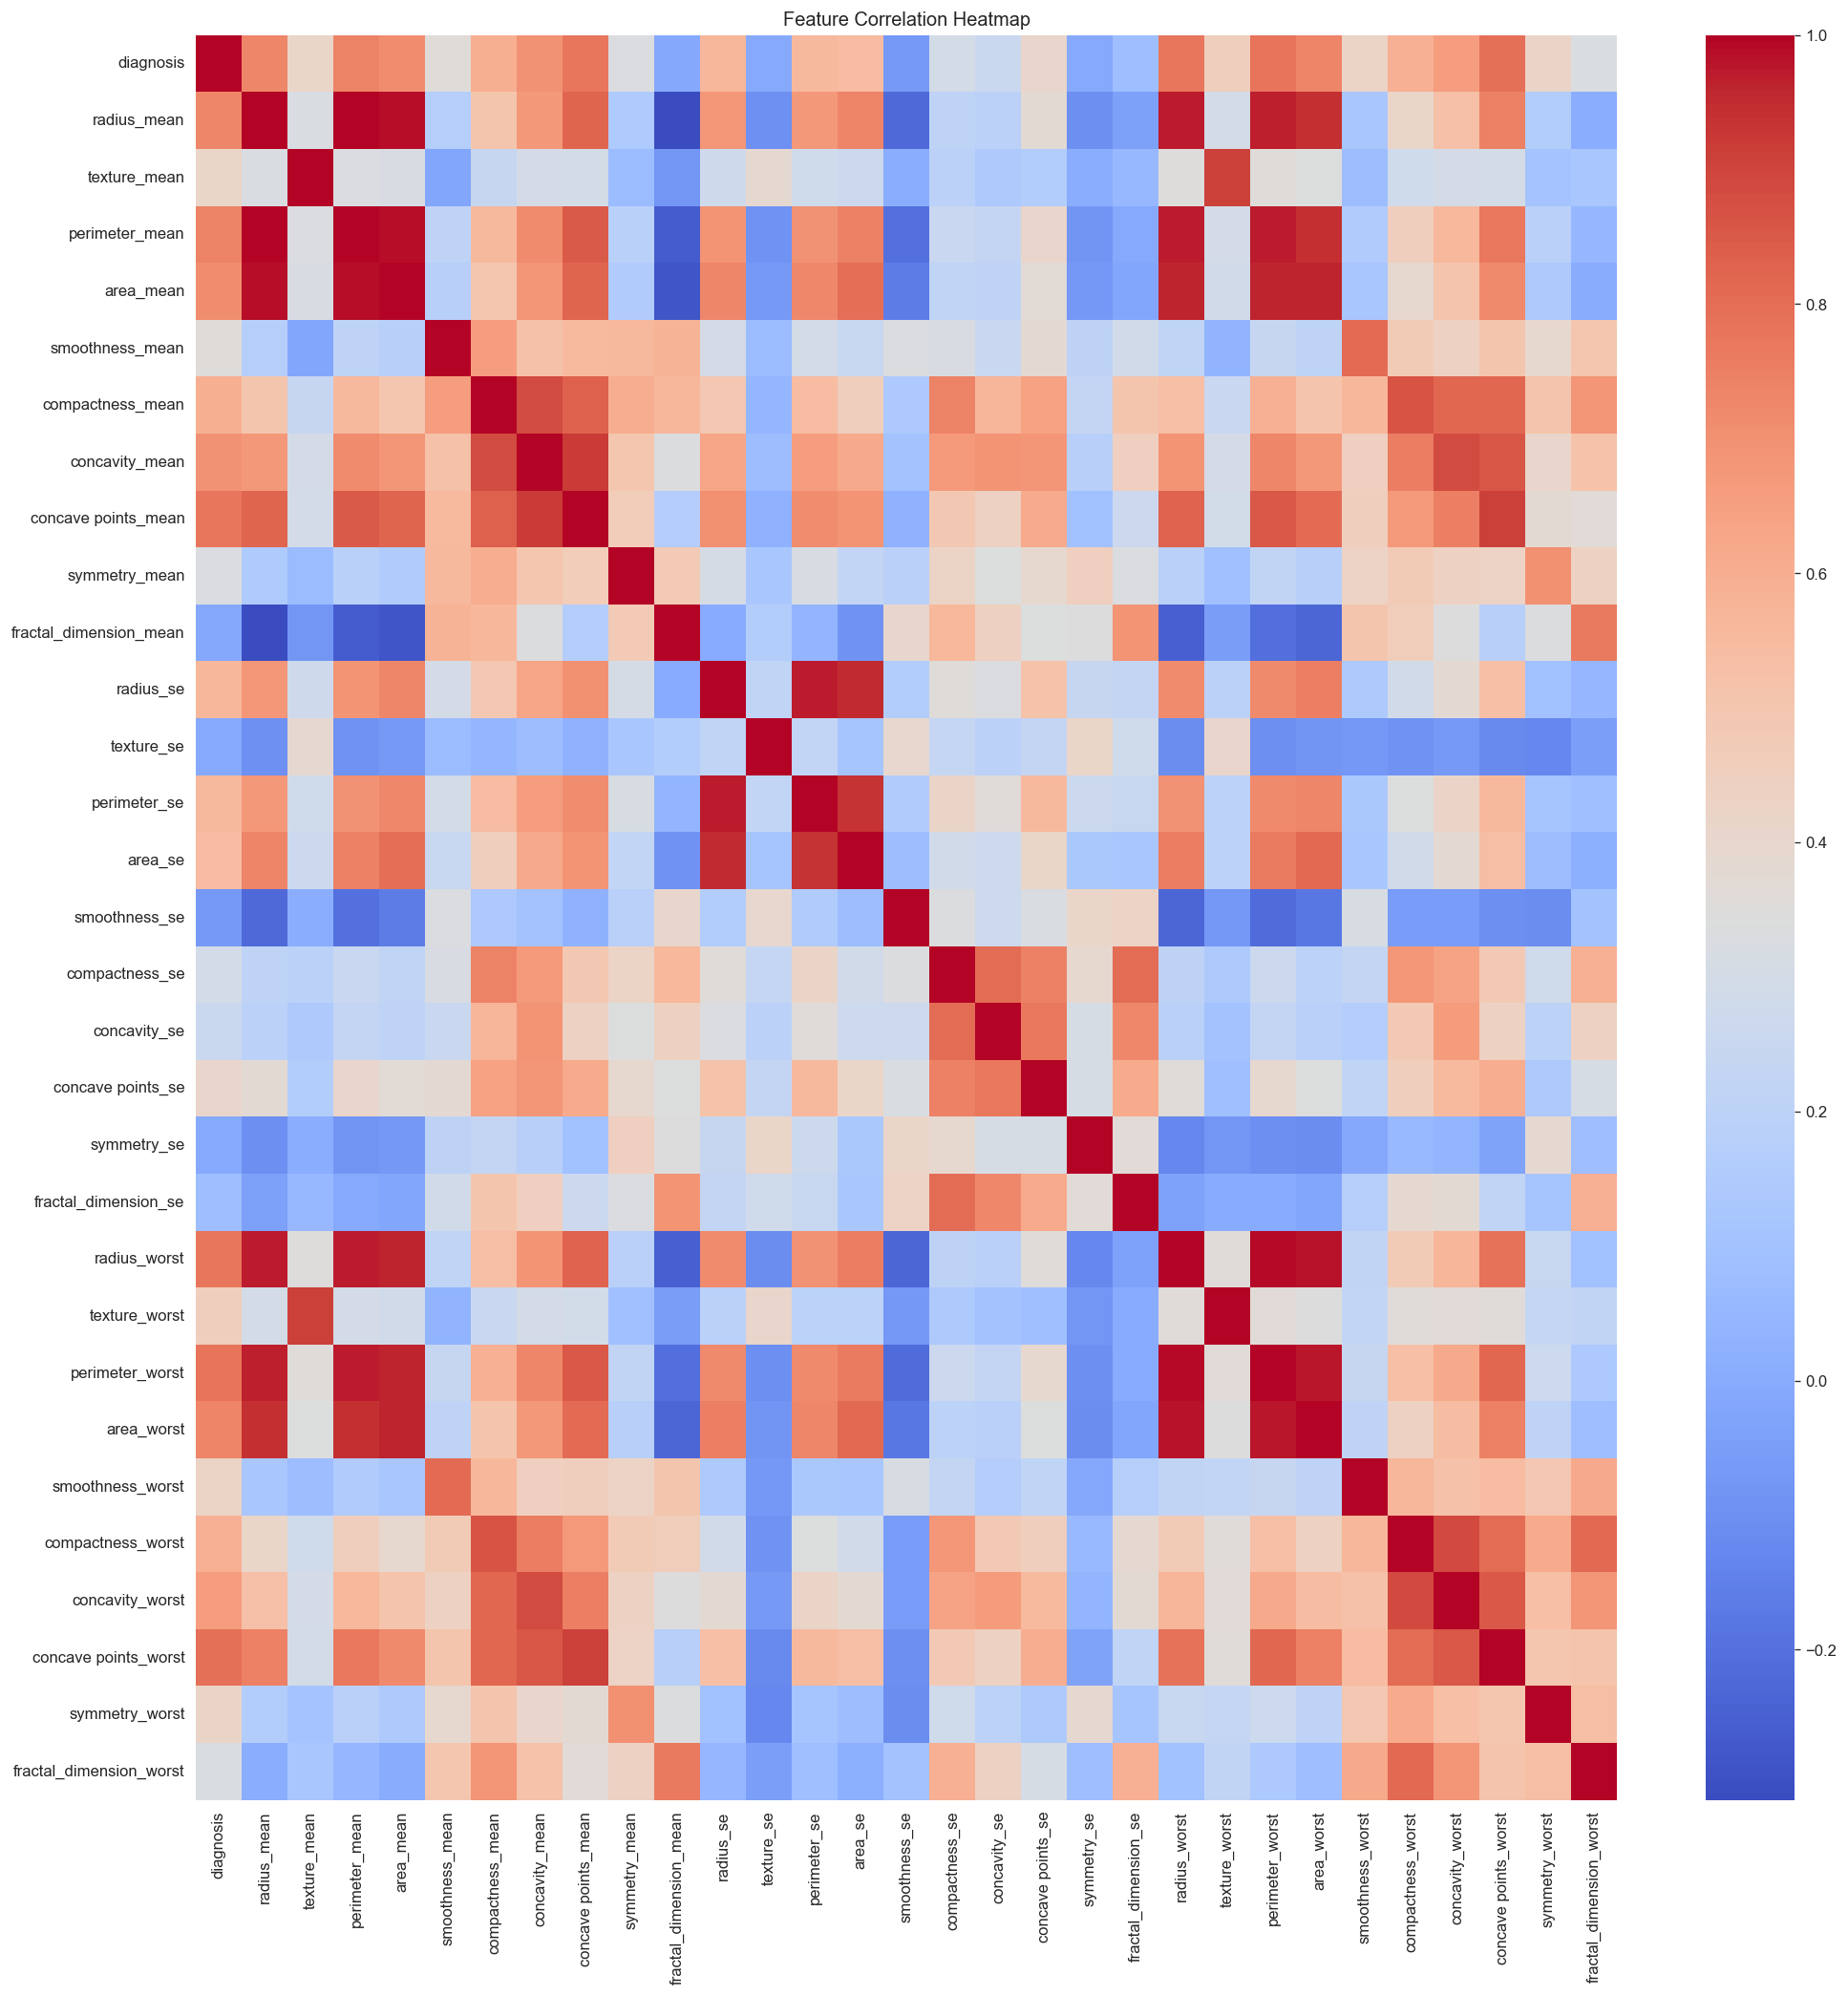

In [113]:
plt.figure(figsize=(20, 20))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train size:      {X_train.shape}")
print(f"Validation size: {X_val.shape}")
print(f"Test size:       {X_test.shape}")


Train size:      (398, 30)
Validation size: (85, 30)
Test size:       (86, 30)


In [ ]:
class Winsorizer(BaseEstimator, TransformerMixin):

    def __init__(self, lower_percentile=0.01, upper_percentile=0.99):
        self.lower_percentile = lower_percentile
        self.upper_percentile = upper_percentile

    def fit(self, X, y=None):
        self.lower = np.percentile(X, self.lower_percentile * 100, axis=0)
        self.upper = np.percentile(X, self.upper_percentile * 100, axis=0)
        return self

    def transform(self, X, y=None):
        X = np.clip(X, self.lower, self.upper)
        return X

In [116]:
def build_pipeline(model):
    return Pipeline([
        ('winsorizer', Winsorizer()),
        ('scaler', MinMaxScaler()),
        ('model', model)
    ])

In [117]:
models = {
    "Logistic Regression": build_pipeline(LogisticRegression(max_iter=500, random_state=42)),
    "Decision Tree": build_pipeline(DecisionTreeClassifier(random_state=42)),
    "Random Forest": build_pipeline(RandomForestClassifier(random_state=42)),
    "SVM": build_pipeline(SVC(random_state=42, probability=True)),
    "Naive Bayes": build_pipeline(GaussianNB()),
    "K-Nearest Neighbors": build_pipeline(KNeighborsClassifier())
}

In [118]:
print("5-Fold Cross Validation Results")

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="recall"
    )

    print(f"{name}")
    print(f"Mean Recall: {scores.mean():.3f}")
    print(f"Standard Deviation: {scores.std():.3f}")
    print("-" * 30)


5-Fold Cross Validation Results
Logistic Regression
Mean Recall: 0.918
Standard Deviation: 0.047
------------------------------
Decision Tree
Mean Recall: 0.905
Standard Deviation: 0.046
------------------------------
Random Forest
Mean Recall: 0.925
Standard Deviation: 0.051
------------------------------
SVM
Mean Recall: 0.932
Standard Deviation: 0.058
------------------------------
Naive Bayes
Mean Recall: 0.898
Standard Deviation: 0.054
------------------------------
K-Nearest Neighbors
Mean Recall: 0.925
Standard Deviation: 0.067
------------------------------


In [119]:
def tune_model(model, params):
    pipeline = Pipeline([
        ('winsorizer', Winsorizer()),
        ('scaler', MinMaxScaler()),
        ('model', model)
    ])

    grid = GridSearchCV(
        pipeline,
        params,
        cv=5,
        scoring="recall",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    print("Best Parameters:", grid.best_params_)
    print(f"Best Recall: {grid.best_score_:.3f}\n")

    return grid.best_estimator_

In [120]:
lr_params = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l2']
}

best_lr = tune_model(
    LogisticRegression(max_iter=500, random_state=42),
    lr_params
)

Best Parameters: {'model__C': 100, 'model__penalty': 'l2'}
Best Recall: 0.939



In [121]:
dt_params = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [2, 3, 4, 5, 6],
    'model__min_samples_split': [2, 3, 4, 5],
    'model__min_samples_leaf': [1, 2, 3, 4]
}

best_dt = tune_model(
    DecisionTreeClassifier(random_state=42),
    dt_params
)

Best Parameters: {'model__criterion': 'gini', 'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}
Best Recall: 0.925



In [122]:
rf_params = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_split': [2, 5],
    'model__max_features': ['sqrt', 'log2']
}

best_rf = tune_model(
    RandomForestClassifier(random_state=42),
    rf_params
)

Best Parameters: {'model__max_depth': None, 'model__max_features': 'log2', 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best Recall: 0.939



In [123]:
svm_params = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['linear', 'rbf'],
    'model__gamma': ['scale', 'auto']
}

best_svm = tune_model(
    SVC(random_state=42, probability=True),
    svm_params
)

Best Parameters: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best Recall: 0.938



In [124]:
knn_params = {
    'model__n_neighbors': [3, 5, 7, 9, 11],
    'model__weights': ['uniform', 'distance'],
    'model__p': [1, 2]
}

best_knn = tune_model(
    KNeighborsClassifier(),
    knn_params
)

Best Parameters: {'model__n_neighbors': 5, 'model__p': 1, 'model__weights': 'uniform'}
Best Recall: 0.932



In [125]:
nb_params = {
    'model__var_smoothing': np.logspace(0, -9, 20)
}

best_nb = tune_model(
    GaussianNB(),
    nb_params
)

Best Parameters: {'model__var_smoothing': np.float64(0.0379269019073225)}
Best Recall: 0.898



In [126]:
final_models = {
    "Logistic Regression (tuned)": best_lr,
    "Decision Tree (tuned)": best_dt,
    "Random Forest (tuned)": best_rf,
    "SVM (tuned)": best_svm,
    "Naive Bayes (tuned)": best_nb,
    "K-Nearest Neighbors (tuned)": best_knn
}

In [127]:
results_val = {}
for name, pipe in final_models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)
    y_proba = pipe.predict_proba(X_val)[:, 1]
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_proba)
    results_val[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC': auc}

results_df = pd.DataFrame(results_val).T
print("\nPerformance on Validation Set:")
print(results_df.round(3))


Performance on Validation Set:
                             Accuracy  Precision  Recall     F1    AUC
Logistic Regression (tuned)     0.976      1.000   0.938  0.968  0.997
Decision Tree (tuned)           0.941      1.000   0.844  0.915  0.933
Random Forest (tuned)           0.965      1.000   0.906  0.951  0.992
SVM (tuned)                     0.976      1.000   0.938  0.968  0.995
Naive Bayes (tuned)             0.929      0.933   0.875  0.903  0.987
K-Nearest Neighbors (tuned)     0.965      1.000   0.906  0.951  0.995


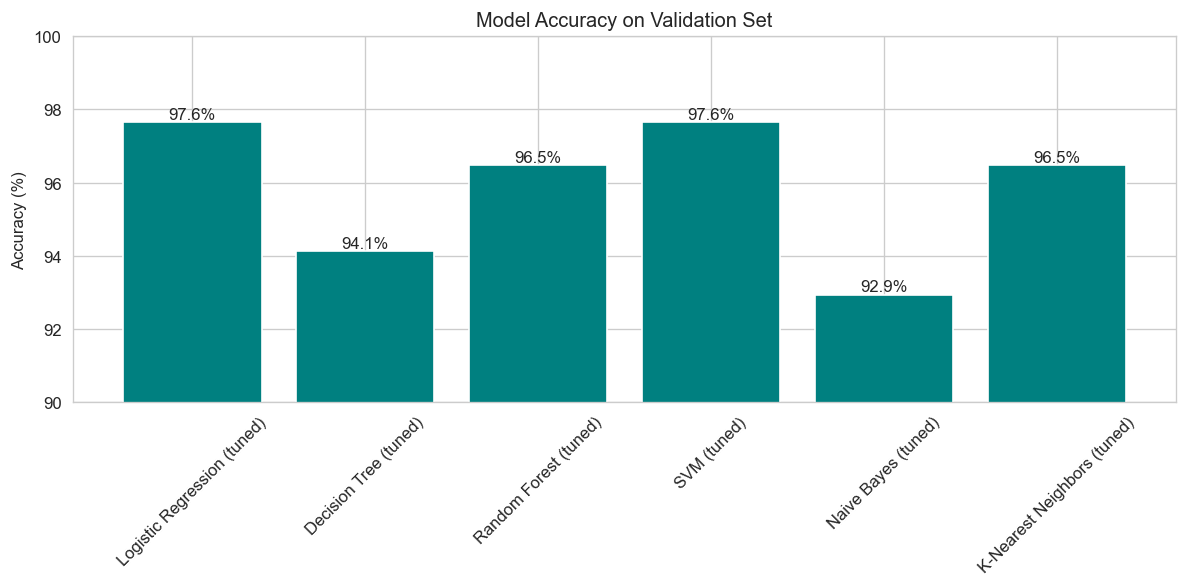

In [128]:
plt.figure(figsize=(10,5))
bars = plt.bar(results_df.index, results_df.Accuracy*100, color='teal')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy on Validation Set')
plt.xticks(rotation=45)
plt.ylim(90, 100)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.1f}%', ha='center')
plt.tight_layout()
plt.show()

In [129]:
best_model_name = results_df['Recall'].idxmax()
best_pipe = final_models[best_model_name]
print(f"\nBest model selected (by validation Recall): {best_model_name}")



Best model selected (by validation Recall): Logistic Regression (tuned)


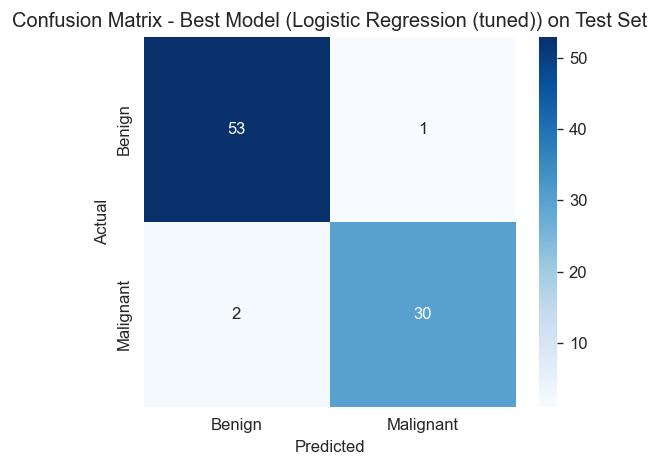


Classification Report (Test Set):
              precision    recall  f1-score   support

      Benign       0.96      0.98      0.97        54
   Malignant       0.97      0.94      0.95        32

    accuracy                           0.97        86
   macro avg       0.97      0.96      0.96        86
weighted avg       0.97      0.97      0.96        86

Test ROC-AUC: 0.998


In [130]:
y_test_pred = best_pipe.predict(X_test)
y_test_proba = best_pipe.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title(f'Confusion Matrix - Best Model ({best_model_name}) on Test Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=['Benign', 'Malignant']))

test_auc = roc_auc_score(y_test, y_test_proba)
print(f"Test ROC-AUC: {test_auc:.3f}")

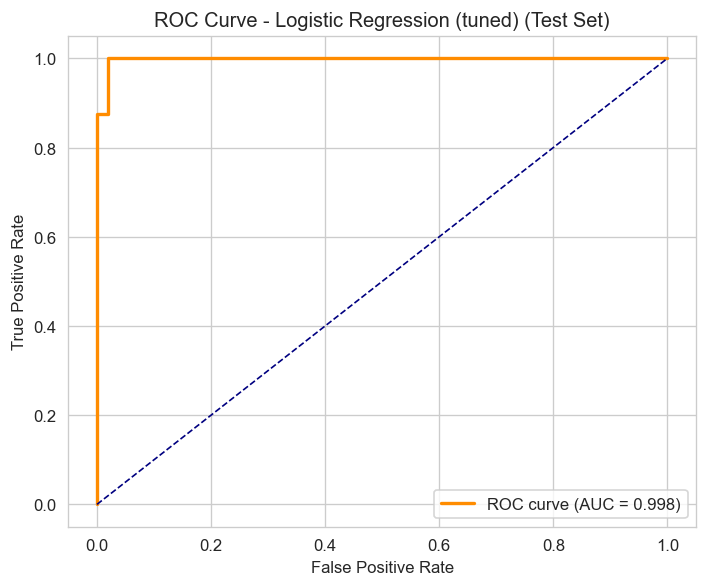

In [131]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {test_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_model_name} (Test Set)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [132]:
print(f"""
Summary
-------
Best model: {best_model_name}
Test Recall:    {recall_score(y_test, y_test_pred):.3f}
Test Precision: {precision_score(y_test, y_test_pred):.3f}
Test AUC:       {test_auc:.3f}
""")


Summary
-------
Best model: Logistic Regression (tuned)
Test Recall:    0.938
Test Precision: 0.968
Test AUC:       0.998

